In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
from sklearn.metrics import confusion_matrix

import torch.nn.functional as F

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns


# reproducibility
torch.manual_seed(0)
np.random.seed(0)


### Dataset Description ###

- The Fashion-MNIST dataset is used in this project. It consists of 70,000 grayscale images of clothing items, each with a resolution of 28×28 pixels. The dataset contains 10 classes, including T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, and Ankle boot.

- The original training set includes 60,000 samples and the test set includes 10,000 samples. In this project, the training set is further split into 50,000 training samples and 10,000 validation samples. All images are normalized and flattened into 784-dimensional vectors to be used as input for a fully connected neural network.

In [74]:
# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(),                 # (1, 28, 28), values in [0,1]
    transforms.Normalize((0.5,), (0.5,)),  # Normalization
    transforms.Lambda(lambda x: x.view(-1))  # flatten to 784
])

train_full = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

# split train / validation
train_size = 50000
val_size = 10000
train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

# Set teh loaders:        
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# # Show the number of samples in each set.
# print("Train samples:", len(train_dataset))
# print("Validation samples:", len(val_dataset))
# print("Test samples:", len(test_dataset))



### Model Architecture ###

- A fully connected neural network (MLP) is used for classification. The input layer takes a 784-dimensional vector corresponding to the flattened 28×28 grayscale image. The network consists of two hidden layers with 128 and 64 neurons, respectively, each followed by a ReLU activation function. Dropout with a rate of 0.3 is applied after each hidden layer to reduce overfitting.

- The output layer contains 10 neurons, corresponding to the 10 classes in the Fashion-MNIST dataset. No softmax activation is applied in the output layer, as the CrossEntropyLoss function internally performs the softmax operation during training.

In [75]:
# We use a fully connected network. (The drop out is optional)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4), 

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.4), 

            nn.Linear(64, 10)
        )
    # We will use different loss function later. So there is no softmax here.

    def forward(self, x):
        return self.net(x)


In [76]:
# Initialize the model, specifies the loss function, optimizer...

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP().to(device)

# Different criterions can be applied:
criterion = nn.CrossEntropyLoss()

# Different optimizers:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [77]:
# This function is only for evaluating the model:
def evaluate(model, loader): # The loader can be train_loader, val_loader, or test_loader.
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0

    with torch.no_grad():
        for x, y in loader:                    # x is the samples(in one batch), and the y is the vector of their labels.
            x, y = x.to(device), y.to(device)  # x.shape = (batch_size, 784)   y.shape = (batch_size,)
            logits = model(x)                  # Evaluate the model, get the logits.
            loss = criterion(logits, y)        # Calculate the loss according to our loss function.

            loss_sum += loss.item() * y.size(0) # aggregate the loss batch to batch.
            preds = logits.argmax(dim=1)        # Get the classification result.
            correct += (preds == y).sum().item() # get the amount of the right predictions in this batch.
            total += y.size(0)

    return loss_sum / total, correct / total

In [78]:
epochs = 20

# Track the loss and accuracy in training set and validation set.
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()  # Set the model to training mode
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()          # Set the gradient to 0. (No accumulation)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()                # back propagation
        optimizer.step()               # Update weights

    # Use the evaluate function we defined above to evaluate the model after every epoch training:
    train_loss, train_acc = evaluate(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    # Collect the loss and accruracy:
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


Epoch 01 | Train Loss: 0.4498, Acc: 0.8368 | Val Loss: 0.4619, Acc: 0.8256
Epoch 02 | Train Loss: 0.3965, Acc: 0.8542 | Val Loss: 0.4123, Acc: 0.8420
Epoch 03 | Train Loss: 0.3730, Acc: 0.8623 | Val Loss: 0.4005, Acc: 0.8500
Epoch 04 | Train Loss: 0.3595, Acc: 0.8657 | Val Loss: 0.3937, Acc: 0.8548
Epoch 05 | Train Loss: 0.3489, Acc: 0.8714 | Val Loss: 0.3886, Acc: 0.8559
Epoch 06 | Train Loss: 0.3450, Acc: 0.8720 | Val Loss: 0.3808, Acc: 0.8595
Epoch 07 | Train Loss: 0.3235, Acc: 0.8794 | Val Loss: 0.3708, Acc: 0.8651
Epoch 08 | Train Loss: 0.3118, Acc: 0.8850 | Val Loss: 0.3571, Acc: 0.8694
Epoch 09 | Train Loss: 0.3048, Acc: 0.8855 | Val Loss: 0.3546, Acc: 0.8689
Epoch 10 | Train Loss: 0.2979, Acc: 0.8874 | Val Loss: 0.3510, Acc: 0.8702
Epoch 11 | Train Loss: 0.2974, Acc: 0.8895 | Val Loss: 0.3532, Acc: 0.8734
Epoch 12 | Train Loss: 0.2967, Acc: 0.8901 | Val Loss: 0.3605, Acc: 0.8692
Epoch 13 | Train Loss: 0.2875, Acc: 0.8897 | Val Loss: 0.3492, Acc: 0.8725
Epoch 14 | Train Loss: 0.

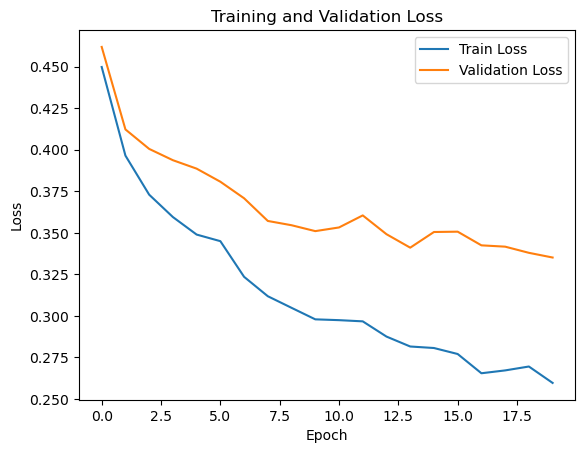

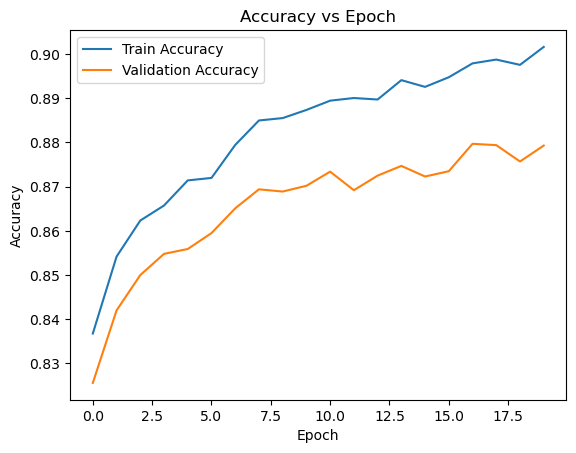

In [79]:
# Draw the loss and accuracy:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy vs Epoch")
plt.show()

Test Accuracy : 0.8717
Test Precision: 0.8709492172162315
Test Recall   : 0.8716999999999999
Test F1-score : 0.87050224239547
[[849   0  13  39   3   4  80   3   9   0]
 [  3 963   1  27   3   0   2   0   1   0]
 [ 22   0 759  15 130   0  72   0   1   1]
 [ 19   4  10 916  27   2  18   0   4   0]
 [  1   1  67  44 816   0  67   0   4   0]
 [  0   0   0   0   0 932   0  45   0  23]
 [159   1  90  44  65   1 622   0  17   1]
 [  0   0   0   0   0  14   0 959   0  27]
 [  3   0   2   9   1   9   7   7 962   0]
 [  0   0   0   0   0   7   1  53   0 939]]


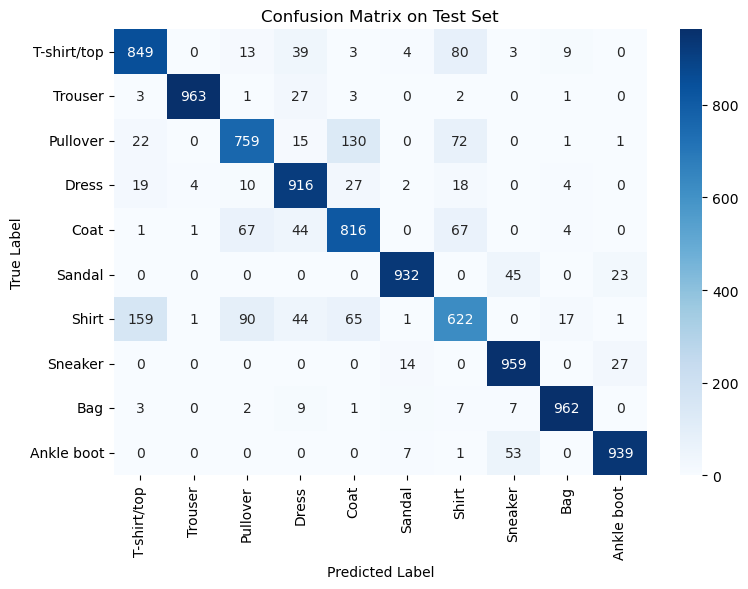

In [80]:
# Plot the confusion matrix on the test set:

model.eval() # Evaluation mode   

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)                 # (batch_size, 10)  forward pass to get the logits
        preds = torch.argmax(logits, 1)   # prediction

        all_preds.append(preds.cpu())    # Put all preditions and all labels into two lists respectively.
        all_labels.append(y.cpu())       # [[the result of batch 1];[the result of batch 2];.....]

# Convert all tensors into a single vector.
all_preds = torch.cat(all_preds).numpy()    # all_preds.shape == (10000,)
all_labels = torch.cat(all_labels).numpy()  # all_labels.shape == (10000,)

test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, average="macro")
test_recall = recall_score(all_labels, all_preds, average="macro")
test_f1 = f1_score(all_labels, all_preds, average="macro")

print("Test Accuracy :", test_acc)
print("Test Precision:", test_precision)
print("Test Recall   :", test_recall)
print("Test F1-score :", test_f1)

cm = confusion_matrix(all_labels, all_preds)
print(cm)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()




In [81]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # -------- Convolutional layers --------
        self.conv1 = nn.Conv2d(
            in_channels=1,    # Fashion-MNIST 是灰度图
            out_channels=32,
            kernel_size=3,
            padding=1         # 保持 28x28
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # -------- Fully connected layers --------
        # 28x28 -> pool -> 14x14 -> pool -> 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (batch_size, 1, 28, 28)

        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        return x
